###### 129_7_quartile_category_with_graph_answer.ipynb  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#cell2
plt.rcParams["font.family"] = "Meiryo"

In [5]:
#cell3
rnd = np.random.default_rng(3)
df = pd.DataFrame(
    rnd.standard_normal(100),
    columns=[
        "Value",
    ],
)
df

,Value
0,2.040919
1,-2.555665
2,0.418099
3,-0.567770
4,-0.452649
...,...
95,-1.730013
96,-0.004414
97,1.213564
98,0.757058


In [6]:
labels = [
    "第1四分位数以下",
    "第2四分位数以下",
    "第3四分位数以下",
    "その他",
]

In [7]:
df["Category"] = pd.qcut(
    df["Value"],
    4,
    labels=labels,
)
df

,Value,Category
0,2.040919,その他
1,-2.555665,第1四分位数以下
2,0.418099,第3四分位数以下
3,-0.567770,第2四分位数以下
4,-0.452649,第2四分位数以下
...,...,...
95,-1.730013,第1四分位数以下
96,-0.004414,第3四分位数以下
97,1.213564,その他
98,0.757058,その他


In [8]:
#cell6
q1 = df["Value"].quantile(0.25)
q2 = df["Value"].quantile(0.50)
q3 = df["Value"].quantile(0.75)

In [10]:
#cell7
mean = df["Value"].mean()
std = df["Value"].std()

In [11]:
#cell8
x = np.linspace(
    df["Value"].min() -0.5,
    df["Value"].max() +0.5,
    500,
)

In [12]:
#cell9
y= (
    1
    / (std * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((x - mean) / std) **2)
)

In [13]:
#cell10
plt.figure(
    figsize=(
        10,
        4,
    )
)

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

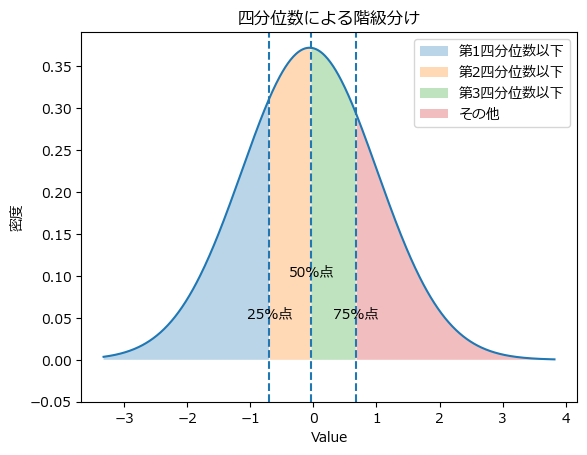

,Value,Category
0,2.040919,その他
1,-2.555665,第1四分位数以下
2,0.418099,第3四分位数以下
3,-0.567770,第2四分位数以下
4,-0.452649,第2四分位数以下
...,...,...
95,-1.730013,第1四分位数以下
96,-0.004414,第3四分位数以下
97,1.213564,その他
98,0.757058,その他


In [39]:
#cell11
plt.plot(
    x,
    y,
)

#cell12

plt.fill_between(
    x,
    y,
    where=x <= q1,
    alpha=0.3,
    label="第1四分位数以下",
)

plt.fill_between(
    x,
    y,
    where=(x > q1) & (x <= q2),
    alpha=0.3,
    label="第2四分位数以下",
)
plt.fill_between(
    x,
    y,
    where=(x > q2) & (x <= q3),
    alpha=0.3,
    label="第3四分位数以下",
)
plt.fill_between(
    x,
    y,
    where=x > q3,
    alpha=0.3,
    label="その他",
)

#cell16

plt.axvline(
    q1,
    linestyle="--",
)
plt.axvline(
    q2,
    linestyle="--",
)
plt.axvline(
    q3,
    linestyle="--",
)

#cell 17
plt.text(
    q1,
    0.05,
    "25%点",
    ha="center",
)
plt.text(
    q2,
    0.1,
    "50%点",
    ha="center",
)
plt.text(
    q3,
    0.05,
    "75%点",
    ha="center",
)

plt.title("四分位数による階級分け",ha="center")
plt.xlabel("Value")
plt.ylabel("密度")
plt.legend()

plt.ylim(
    bottom=-0.05
)
plt.show()
df